# Preliminary problems
* some basic yet fundamental problems that are worth knowing and, by the way, an introduction to PyTorch library
* single perceptron, two coupled perceptrons, simplest deep model and the Universal Approximation Theorem

## Logic gates and Perceptrons

#### XOR issue

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

Let's start with training single perceptron model to simulate basic logic gates

In [ ]:
# define basic logic gates
X = torch.tensor([[0,0], [0,1], [1,0], [1,1]], dtype=torch.float32)
gates = ("OR", "AND", "XOR")
# labels
Y_or = torch.tensor([0, 1, 1, 1], dtype=torch.float32).view(-1, 1)
Y_and = torch.tensor([0, 0, 0, 1], dtype=torch.float32).view(-1, 1)
Y_xor = torch.tensor([0, 1, 1, 0], dtype=torch.float32).view(-1, 1)

# let's define a model
class Perceptron(torch.nn.Module):
    # constructor
    def __init__(self, size):
        super(Perceptron, self).__init__()
        self.single_neuron = nn.Linear(size, 1)
        self.sigmoid = nn.Sigmoid()
    # mathod called once the model is executed
    def forward(self, x):
        x = self.single_neuron(x)
        return self.sigmoid(x)

# define model and learnig scheme
model = Perceptron(size=2)
optimizer = optim.SGD(model.parameters(), lr=0.5)
MSE = nn.MSELoss()

# train
N_epochs = 10000

for gate, y_gt in zip(gates, (Y_or, Y_and, Y_xor)):
    train_loss = []
    model.train()  # turn on the training mode
    for _ in range(N_epochs):
        # this will zero out the gradients for this batch
        optimizer.zero_grad()
        # make predictions
        y_pred = model(X)
        # calculate the MSE loss
        loss = MSE(y_pred, y_gt)
        # backpropagate the loss
        loss.backward()
        # update the model weights (with assumed learning rate)
        optimizer.step()
        train_loss.append(loss.item())
    print("last loss value = ", train_loss[-1])
    model.eval()
    for i, x in enumerate(X):
        print("{} {} {} -> {}".format(x[0].item(), gate, x[1].item(), model(x).item()))
    print()


last loss value =  0.0005039861425757408
0.0 OR 0.0 -> 0.03357478603720665
0.0 OR 1.0 -> 0.978922963142395
1.0 OR 0.0 -> 0.9789232611656189
1.0 OR 1.0 -> 0.9999839067459106

last loss value =  0.0007682038703933358
0.0 AND 0.0 -> 3.5399974876781926e-05
0.0 AND 1.0 -> 0.030023949220776558
1.0 AND 0.0 -> 0.030023949220776558
1.0 AND 1.0 -> 0.9643674492835999

last loss value =  0.25006067752838135
0.0 XOR 0.0 -> 0.009001029655337334
0.0 XOR 1.0 -> 0.9909678101539612
1.0 XOR 0.0 -> 0.9909678101539612
1.0 XOR 1.0 -> 0.9999992847442627



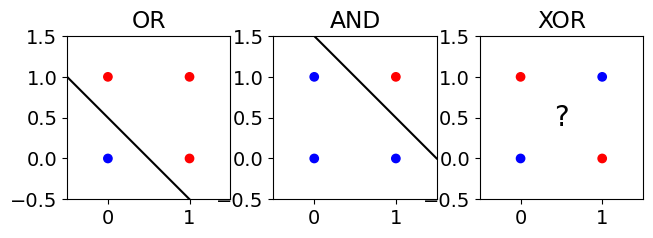

In [ ]:
import matplotlib.pyplot as plt

for i, Y in enumerate([Y_or, Y_and, Y_xor]):
    ax = plt.subplot(131 + i)
    ax.set_xlim([-0.5, 1.5])
    ax.set_ylim([-0.5, 1.5])
    ax.set_aspect('equal')

    plt.title(gates[i])
    plt.scatter(*zip(*X), c=Y, cmap='bwr')

    if i == 0:
        plt.plot([-0.5, 1], [1, -0.5], 'k')
    elif i == 1:
        plt.plot([0, 1.5], [1.5, 0], 'k')
    else:
        plt.text(0.5, 0.5, s="?", fontsize=20, ha='center', va='center')

plt.tight_layout()

- single perceptron is not able to capture XOR gate working

Now stack two perceptons and make the network deep

In [ ]:
class PerceptronDeep(torch.nn.Module):
    # constructor
    def __init__(self, hidden_size):
        super(PerceptronDeep, self).__init__()
        self.hidden_layer = nn.Linear(2, hidden_size)
        self.output_layer = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    # mathod called once the model is executed
    def forward(self, x):
        x = self.hidden_layer(x)
        x = self.sigmoid(x)
        x = self.output_layer(x)
        return self.sigmoid(x)

# train
N_epochs = 100000

for gate, y_gt in zip(gates, (Y_or, Y_and, Y_xor)):
    # define model and learnig scheme
    model = PerceptronDeep(hidden_size=2)
    optimizer = optim.SGD(model.parameters(), lr=0.5)
    # start training
    train_loss = []
    model.train()  # turn on the training mode
    for _ in range(N_epochs):
        # this will zero out the gradients for this batch
        optimizer.zero_grad()
        # make predictions
        y_pred = model(X)
        # calculate the MSE loss
        loss = MSE(y_pred, y_gt)
        # backpropagate the loss
        loss.backward()
        # update the model weights (with assumed learning rate)
        optimizer.step()
        train_loss.append(loss.item())
    print("last loss value = ", train_loss[-1])
    model.eval()
    for i, x in enumerate(X):
        print("{} {} {} -> {}".format(x[0].item(), gate, x[1].item(), model(x).item()))
    print()

last loss value =  1.9889625036739744e-05
0.0 OR 0.0 -> 0.0070689041167497635
0.0 OR 1.0 -> 0.9961608648300171
1.0 OR 0.0 -> 0.99623703956604
1.0 OR 1.0 -> 0.9991700649261475

last loss value =  1.5360861652879976e-05
0.0 AND 0.0 -> 0.00022210822498891503
0.0 AND 1.0 -> 0.003941709641367197
1.0 AND 0.0 -> 0.003929676953703165
1.0 AND 1.0 -> 0.994485080242157

last loss value =  5.1825129048665985e-05
0.0 XOR 0.0 -> 0.007195078767836094
0.0 XOR 1.0 -> 0.9932025074958801
1.0 XOR 0.0 -> 0.9917524456977844
1.0 XOR 1.0 -> 0.006426684092730284



- ... while the deep model is able to capture XOR gate.

## Simple regression and Universal Approximation Theorem

Let's get back to (flat) perceptron.
- before we begin, let's generate some complex function:

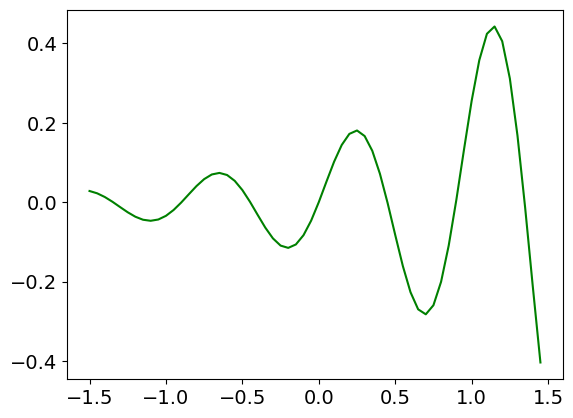

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

# define regression problem and generate synthetic data
X = torch.arange(-1.5, 1.5, 0.05).view(-1, 1).type(torch.float32)
y = torch.sin(X*7.)*torch.exp(X)/7.
plt.plot(X, y, 'g')
plt.show()

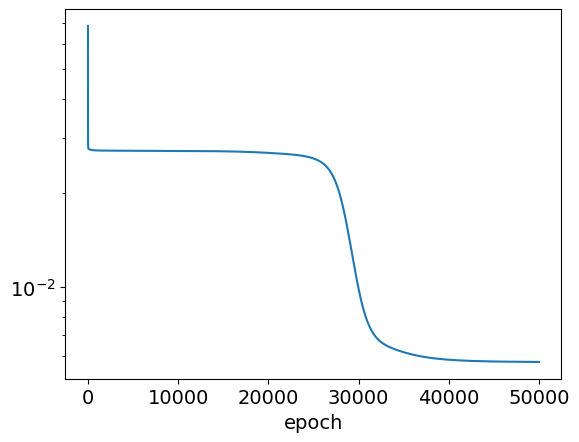

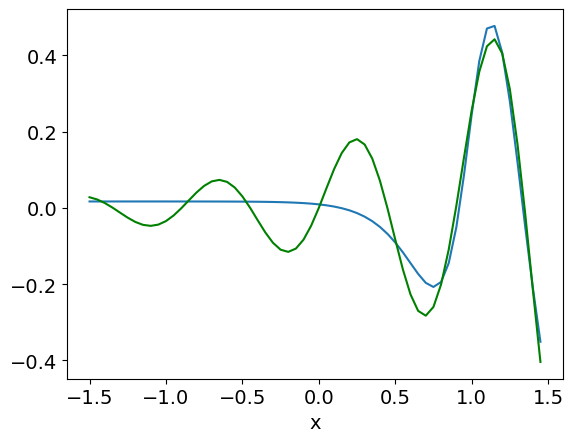

In [ ]:
class PerceptronDeep(torch.nn.Module):
    # constructor
    def __init__(self, hidden_size):
        super(PerceptronDeep, self).__init__()
        self.hidden_layer = nn.Linear(1, hidden_size)
        self.output_layer = nn.Linear(hidden_size, 1)
        self.activation = nn.Tanh()  # Sigmoid has non-negative values
    # mathod called once the model is executed
    def forward(self, x):
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

# narrow model
model = PerceptronDeep(hidden_size=2)

optimizer = optim.SGD(model.parameters(), lr=0.2)
MSE = nn.MSELoss()

# train
N_epochs = 50000
train_loss = []
model.train()  # turn on the training mode
for _ in range(N_epochs):
    # this will zero out the gradients for this batch
    optimizer.zero_grad()
    # make predictions
    y_pred = model(X)
    # calculate the MSE loss
    loss = MSE(y_pred, y)
    # backpropagate the loss
    loss.backward()
    # update the model weights (with assumed learning rate)
    optimizer.step()
    train_loss.append(loss.item())

plt.plot(train_loss)
plt.xlabel('epoch')
plt.yscale('log')
plt.show()

model.eval()
plt.plot(X.numpy(), model(X).detach().numpy())
plt.plot(X.numpy(), y.numpy(), 'g')
plt.xlabel('x')
plt.yscale('linear')
plt.show()

- poor fit, model has too small capacity.

Do the same but with much wider model:

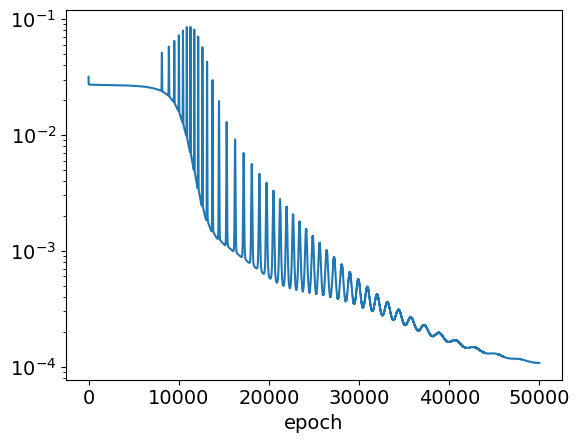

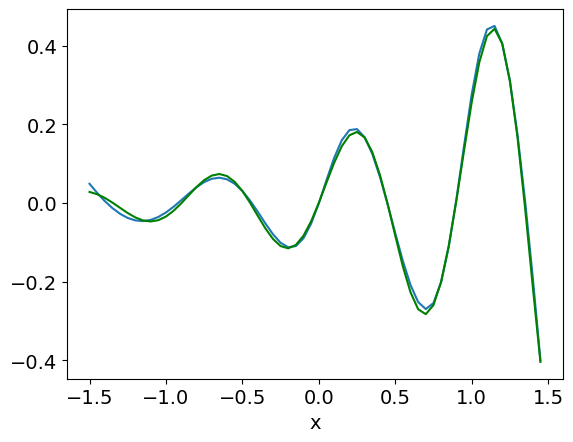

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# wider model
model = PerceptronDeep(hidden_size=20).to(device)
X, y = X.to(device), y.to(device)

# train
optimizer = optim.SGD(model.parameters(), lr=0.2)
N_epochs = 50000

train_loss = []
model.train()  # turn on the training mode
for _ in range(N_epochs):
    # this will zero out the gradients for this batch
    optimizer.zero_grad()
    # make predictions
    y_pred = model(X)
    # calculate the MSE loss
    loss = MSE(y_pred, y)
    # backpropagate the loss
    loss.backward()
    # update the model weights (with assumed learning rate)
    optimizer.step()
    train_loss.append(loss.item())

plt.plot(train_loss)
plt.xlabel('epoch')
plt.yscale('log')
plt.show()

model.eval()
plt.plot(X.cpu(), model(X).cpu().detach())
plt.plot(X.cpu(), y.cpu(), 'g')
plt.xlabel('x')
plt.yscale('linear')
plt.show()

- quite nice fit, Universal Approximation Theorem holds.

Now, let's try with narrower but deeper model:

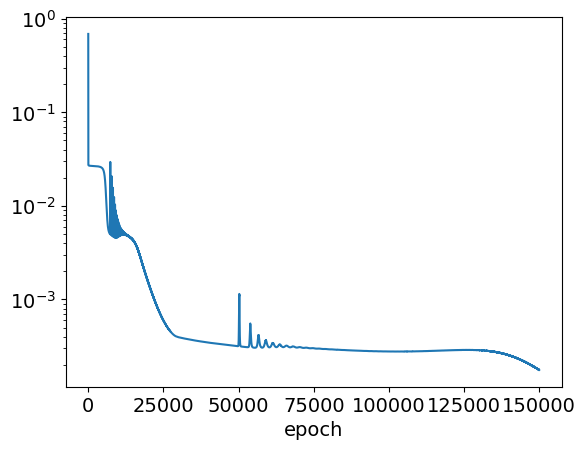

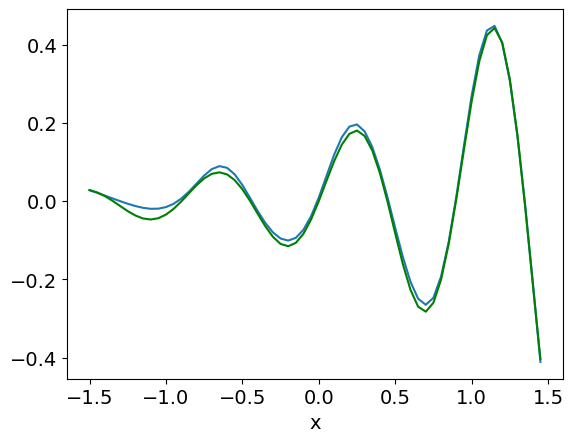

In [ ]:
class PerceptronDeeper(torch.nn.Module):
    # constructor
    def __init__(self, hidden_size):
        super(PerceptronDeeper, self).__init__()
        self.hidden_layer_1st = nn.Linear(1, hidden_size)
        self.hidden_layer_2nd = nn.Linear(hidden_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, 1)
        self.activation = nn.Tanh()  # Sigmoid has non-negative values
    # mathod called once the model is executed
    def forward(self, x):
        x = self.hidden_layer_1st(x)
        x = self.activation(x)
        x = self.hidden_layer_2nd(x)
        x = self.activation(x)
        return self.output_layer(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X, y = X.to(device), y.to(device)

# narrow model
model = PerceptronDeeper(hidden_size=4).to(device)

optimizer = optim.SGD(model.parameters(), lr=0.2)
MSE = nn.MSELoss()

# train
N_epochs = 150000
train_loss = []
model.train()  # turn on the training mode
for _ in range(N_epochs):
    # this will zero out the gradients for this batch
    optimizer.zero_grad()
    # make predictions
    y_pred = model(X)
    # calculate the MSE loss
    loss = MSE(y_pred, y)
    # backpropagate the loss
    loss.backward()
    # update the model weights (with assumed learning rate)
    optimizer.step()
    train_loss.append(loss.item())

plt.plot(train_loss)
plt.xlabel('epoch')
plt.yscale('log')
plt.show()

model.eval()
plt.plot(X.cpu(), model(X).cpu().detach())
plt.plot(X.cpu(), y.cpu(), 'g')
plt.xlabel('x')
plt.yscale('linear')
plt.show()

- deeper model with 12 units (3 layers each of 4 units) gives almost the same fit as the shalower but much wider model (1 layer of 20 units),
- deeper model (typically) takes longer to train.

## Tasks to do
1. 
* in case of XOR learning please draw the *learned* bounday over $X_1, X_2$ space 
* try to learn neural network adding two binary numbers or performing multiplication by *two* (note that result should also be some binary number, mind the carry bit),
    * two-digit numbers are fine; but you can try with larger and test *generalization*. 
2. 
* Let us test *expressivity*: compare two MLP NNs, shallow: 1 hidden layer, deep: 3 hidden layers (2 and 4 Linear layers, respectively). Design the networks so that the number of parameters in both is similar (e.g., the number of parameters in the shallow network is $3w+1$ — do you understand why?). Increase the number of parameters and train each model. Finally, compare the MSE of the NN prediction, NN(x), as a function of the number of parameters for both NNs. Assume shallow_widths = [4, 8, 16, 32, 64, 128] and adjust the deep network width accordingly. Check 5k vs 50k training epochs — why does this matter?
* Let us test *generalization*: remove all training points from the interval $x\in[-0.5,0.5]$ and train MLPs with different widths and depths on the remaining data. Compare their predictions inside the missing region. Does increasing the number of parameters improve the prediction? Does higher expressivity necessarily imply better generalization?